In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

df = pl.read_parquet("out/1_work-medium_lz4.parquet")

df

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg
i64,i64,i64,i64,i64,i64,i64,i32,str,str
4,0,1,1714,4096,15695,5526,1,"""work-medium""","""lz4"""
4,0,2,1227,4096,8981,3598,1,"""work-medium""","""lz4"""
4,0,3,1563,4096,10185,3845,1,"""work-medium""","""lz4"""
4,0,4,1396,4096,9050,3529,1,"""work-medium""","""lz4"""
4,0,5,956,4096,6652,3064,1,"""work-medium""","""lz4"""
…,…,…,…,…,…,…,…,…,…
4,2,4529,1435,4096,9922,3852,1,"""work-medium""","""lz4"""
4,2,4530,2070,4096,13495,5021,1,"""work-medium""","""lz4"""
4,2,4531,969,4096,7581,3677,1,"""work-medium""","""lz4"""


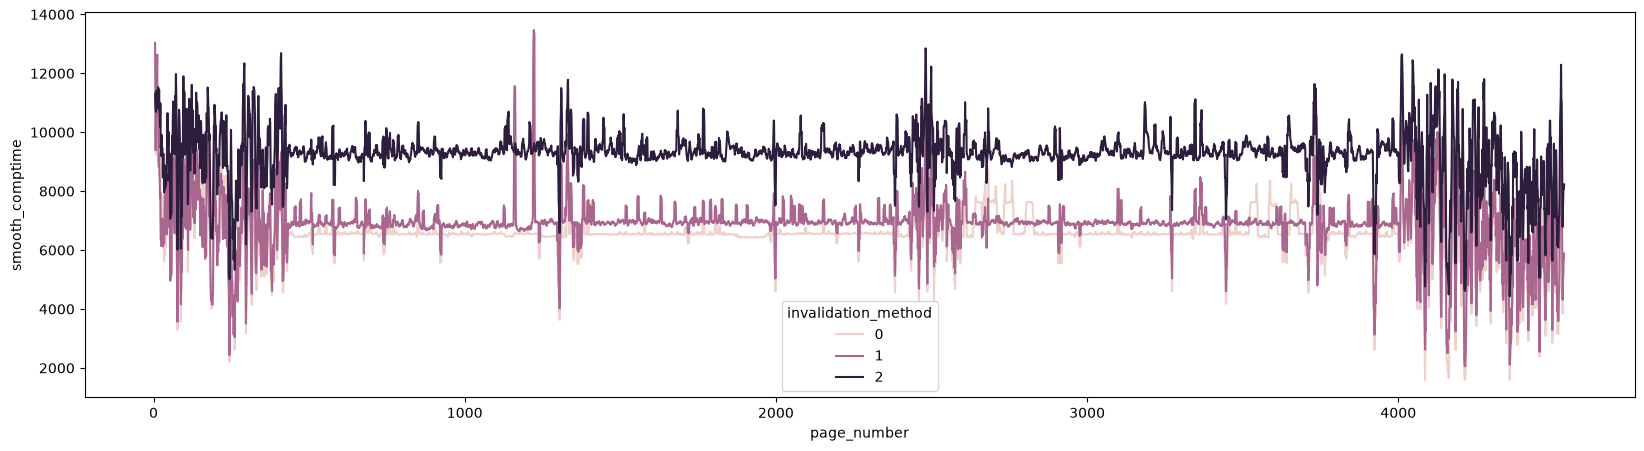

In [7]:
df1 = df.with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=5)
    .over(["alg", "invalidation_method"])
    .alias("smooth_comptime")
)

plt.figure(figsize=(20,5))
ax = sns.lineplot(
    df1,
    x="page_number",
    y="smooth_comptime",
    hue="invalidation_method"
)